In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import resources

In [2]:
def generate_benzene_geometry():
    """
    Generate coordinates for benzene molecule: 6 carbon + 6 hydrogen atoms for Shirkov 2024 (different orientation than ours)
    """
    rc = 1.3915  # Carbon ring radius (in Angstrom)
    rh = 1.080   # C–H bond length (in Angstrom)
    rh1 = rc + rh

    # Constants used in hexagonal arrangement
    ax = [1, 0.5, -0.5, -1, -0.5, 0.5]
    ay = [0, np.sqrt(3)/2, np.sqrt(3)/2, 0, -np.sqrt(3)/2, -np.sqrt(3)/2]

    coords = np.zeros((3, 12))  # (x, y, z) for 12 atoms

    # Carbon atoms
    for i in range(6):
        coords[0, i] = ax[i] * rc
        coords[1, i] = ay[i] * rc

    # Hydrogen atoms
    for i in range(6):
        coords[0, i+6] = ax[i] * rh1
        coords[1, i+6] = ay[i] * rh1

    return coords

def read_parameters(filename="params.txt"):
    """Read PES parameters from a file and convert to atomic units."""
    with resources.open_text("HeBz", filename) as f:
        lines = f.readlines()
    xpar = []
    for line in lines:
        p = line.split()
        xpar.append(float(p[1]))
    return xpar

In [3]:
def _short(x,y,z):
    par = read_parameters()
    x0 = generate_benzene_geometry()
    # Rotate x,y,z by 30 degrees to maintain consistency with the other potentials.
    xr = x * np.cos(-30.0 * np.pi/180.0) - y * np.sin(-30.0 * np.pi/180.0)
    yr = x * np.sin(-30.0 * np.pi/180.0) + y * np.cos(-30.0 * np.pi/180.0)
    x = xr
    y = yr
    # Pre-allocate outputs
    na = 6
    na2 = 12

    # Cartesian to Spherical conversion
    r = np.sqrt(x**2 + y**2 + z**2)
    ph0 = np.arctan2(y,x)
    th0 = np.arccos(z/r)
    tt = np.cos(th0)
    fi = ph0
    #print(r,ph0,th0,tt,fi)
    # Extract parameters
    (re, ae, c0, v0, c3, c4, c5, c6, c7, c8, c12, c112, c1122, c1112, c11112,
     c11122, c111222, c111112, c111122, c123, c1123, c11223, c11123, c112233,
     reh, aeh, v0h, d3, d4, d5, d6, d12, d112, d1122, d1112, dc12, dc112,
     r0, gama, de, x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12) = par[:52]

    are = ae / re
    areh = aeh / reh

    # Initialize interaction terms
    v_terms = np.zeros(15)
    v123_terms = np.zeros(5)
    vdw = 0.0

    # First triple loop for atoms 1 to na
    for k in range(na):
        dxk = x - x0[0, k]
        dyk = y - x0[1, k]
        dzk = z - x0[2, k]
        rrk = dxk**2 + dyk**2 + dzk**2
        rk = np.sqrt(rrk)
        rkk = rk - re
        rk2 = rrk / re**2
        rk6 = rk2**3
        vk = 1.0 - np.exp(-rkk * are)
        wk = vk**2 * (1 + vk * (c3 + vk * (c4 + vk * (c5 + vk * (c6 + vk * (c7 + vk * c8)))))
        )
        v_terms[0] += wk  # v11

        for l in range(k+1, na):
            dxl = x - x0[0, l]
            dyl = y - x0[1, l]
            dzl = z - x0[2, l]
            rrl = dxl**2 + dyl**2 + dzl**2
            rl = np.sqrt(rrl)
            rll = rl - re
            vl = 1.0 - np.exp(-rll * are)

            v_terms[1] += vk * vl               # v12
            v_terms[2] += vk**2 * vl + vk * vl**2     # v112
            v_terms[3] += vk**2 * vl**2               # v1122
            v_terms[4] += vk**3 * vl + vl**3 * vk     # v1112
            v_terms[5] += vk**4 * vl + vl**4 * vk     # v11112
            v_terms[6] += vk**3 * vl**2 + vl**3 * vk**2  # v11122
            v_terms[7] += vk**5 * vl + vl**5 * vk     # v111112
            v_terms[8] += vk**4 * vl**2 + vl**4 * vk**2  # v111122
            v_terms[9] += vk**3 * vl**3               # v111222

            for m in range(l+1, na):
                dxm = x - x0[0, m]
                dym = y - x0[1, m]
                dzm = z - x0[2, m]
                rm = np.sqrt(dxm**2 + dym**2 + dzm**2)
                rmm = rm - re
                vm = 1.0 - np.exp(-rmm * are)

                v123_terms[0] += vk * vl * vm
                v123_terms[1] += vk**2 * vl * vm + vk * vl**2 * vm + vk * vl * vm**2
                v123_terms[2] += vk**2 * vl**2 * vm + vk**2 * vl * vm**2 + vk * vl**2 * vm**2
                v123_terms[3] += vk**3 * vl * vm + vk * vl**3 * vm + vk * vl * vm**3
                v123_terms[4] += vk**2 * vl**2 * vm**2

    # First potential sum
    pt1 = (v_terms[0] + v_terms[1]*c12 + v_terms[2]*c112 + v_terms[3]*c1122 +
           v_terms[4]*c1112 + v_terms[5]*c11112)
    pt2 = (v_terms[6]*c11122 + v_terms[7]*c111112 + v_terms[8]*c111122 +
           v_terms[9]*c111222)
    p = pt1 + pt2 + v123_terms[0]*c123 + v123_terms[1]*c1123 + v123_terms[2]*c11223 \
        + v123_terms[3]*c11123 + v123_terms[4]*c112233

    # Reset some terms for second part
    v_terms[:5] = 0
    w_terms = np.zeros(3)  # v12, w112, w12

    # Loop for atoms 7 to na2
    for k in range(6, na2):  # 0-indexed in Python
        dxk = x - x0[0, k]
        dyk = y - x0[1, k]
        dzk = z - x0[2, k]
        rk = np.sqrt(dxk**2 + dyk**2 + dzk**2)
        rkk = rk - reh
        vk = 1.0 - np.exp(-rkk * areh)
        wk = vk**2 * (1 + vk * (d3 + vk * (d4 + vk * (d5 + vk * d6))))
        v_terms[0] += wk  # v11

        for l in range(k+1, na2):
            dxl = x - x0[0, l]
            dyl = y - x0[1, l]
            dzl = z - x0[2, l]
            rl = np.sqrt(dxl**2 + dyl**2 + dzl**2)
            rll = rl - reh
            vl = 1.0 - np.exp(-rll * areh)

            v_terms[1] += vk * vl         # v12
            v_terms[2] += vk**2 * vl + vk * vl**2  # v112
            v_terms[3] += vk**2 * vl**2           # v1122
            v_terms[4] += vk**3 * vl + vl**3 * vk  # v1112

        for l in range(na):
            dxl = x - x0[0, l]
            dyl = y - x0[1, l]
            dzl = z - x0[2, l]
            rl = np.sqrt(dxl**2 + dyl**2 + dzl**2)
            rll = rl - re
            vl = 1.0 - np.exp(-rll * are)
            w_terms[1] += vk * vl  # w12
            w_terms[2] += vk**2 * vl + vk * vl**2  # w112

    # Second potential sum
    ph = (v_terms[0] + v_terms[1]*d12 + v_terms[2]*d112 + 
          v_terms[3]*d1122 + v_terms[4]*d1112 + 
          w_terms[1]*dc12 + w_terms[2]*dc112)
    # Switching functions
    r1 = np.sqrt(x**2 + y**2 + z**2)
    h_short = 1.0 / (1.0 + np.exp(gama * (r1 - r0))) / r1
    h_long = 1.0 / (1.0 + np.exp(-gama * (r1 - r0)))
    
    v3 = (v0h * ph + v0 * p + c0)*h_short
    return v3
    
def _long(x,y,z):
    par = read_parameters()
    x0 = generate_benzene_geometry()
    # Rotate x,y,z by 30 degrees to maintain consistency with the other potentials.
    xr = x * np.cos(-30.0 * np.pi/180.0) - y * np.sin(-30.0 * np.pi/180.0)
    yr = x * np.sin(-30.0 * np.pi/180.0) + y * np.cos(-30.0 * np.pi/180.0)
    x = xr
    y = yr
    # Pre-allocate outputs
    na = 6
    na2 = 12

    # Cartesian to Spherical conversion
    r = np.sqrt(x**2 + y**2 + z**2)
    ph0 = np.arctan2(y,x)
    th0 = np.arccos(z/r)
    tt = np.cos(th0)
    fi = ph0
    #print(r,ph0,th0,tt,fi)
    # Extract parameters
    (re, ae, c0, v0, c3, c4, c5, c6, c7, c8, c12, c112, c1122, c1112, c11112,
     c11122, c111222, c111112, c111122, c123, c1123, c11223, c11123, c112233,
     reh, aeh, v0h, d3, d4, d5, d6, d12, d112, d1122, d1112, dc12, dc112,
     r0, gama, de, x1, x2, x3, x4, x5, x6, x7, x8, x9, x10, x11, x12) = par[:52]

    # Switching functions
    r1 = np.sqrt(x**2 + y**2 + z**2)
    h_short = 1.0 / (1.0 + np.exp(gama * (r1 - r0))) / r1
    h_long = 1.0 / (1.0 + np.exp(-gama * (r1 - r0)))

    # Angular dependence
    normm1 = np.sqrt(5.0) / 5.0
    normm2 = np.sqrt(13.0) / 13.0
    normm3 = 0.1792151994e-4

    p1 = -x1 / r**6 - x2 / r**8 - x3 / r**10 - x4 / r**12
    p2 = -normm1 * (1.5 * tt**2 - 0.5) * (x5 / r**6 + x6 / r**8 + x7 / r**10 + x8 / r**12)
    p3 = -normm2 * (3.0/8.0 + 35.0/8.0 * tt**4 - 15.0/4.0 * tt**2)
    p4 = (x9 / r**8 + x10 / r**10 + x11 / r**12)
    p5 = -normm3 * 10395.0 * (1 - tt**2)**3 * np.cos(6 * fi) * x12 / r**10
    vdw = p1 + p2 + p3 * p4 + p5

    v3 = vdw*h_long
    return v3

In [4]:
short = np.vectorize(_short)
long = np.vectorize(_long)

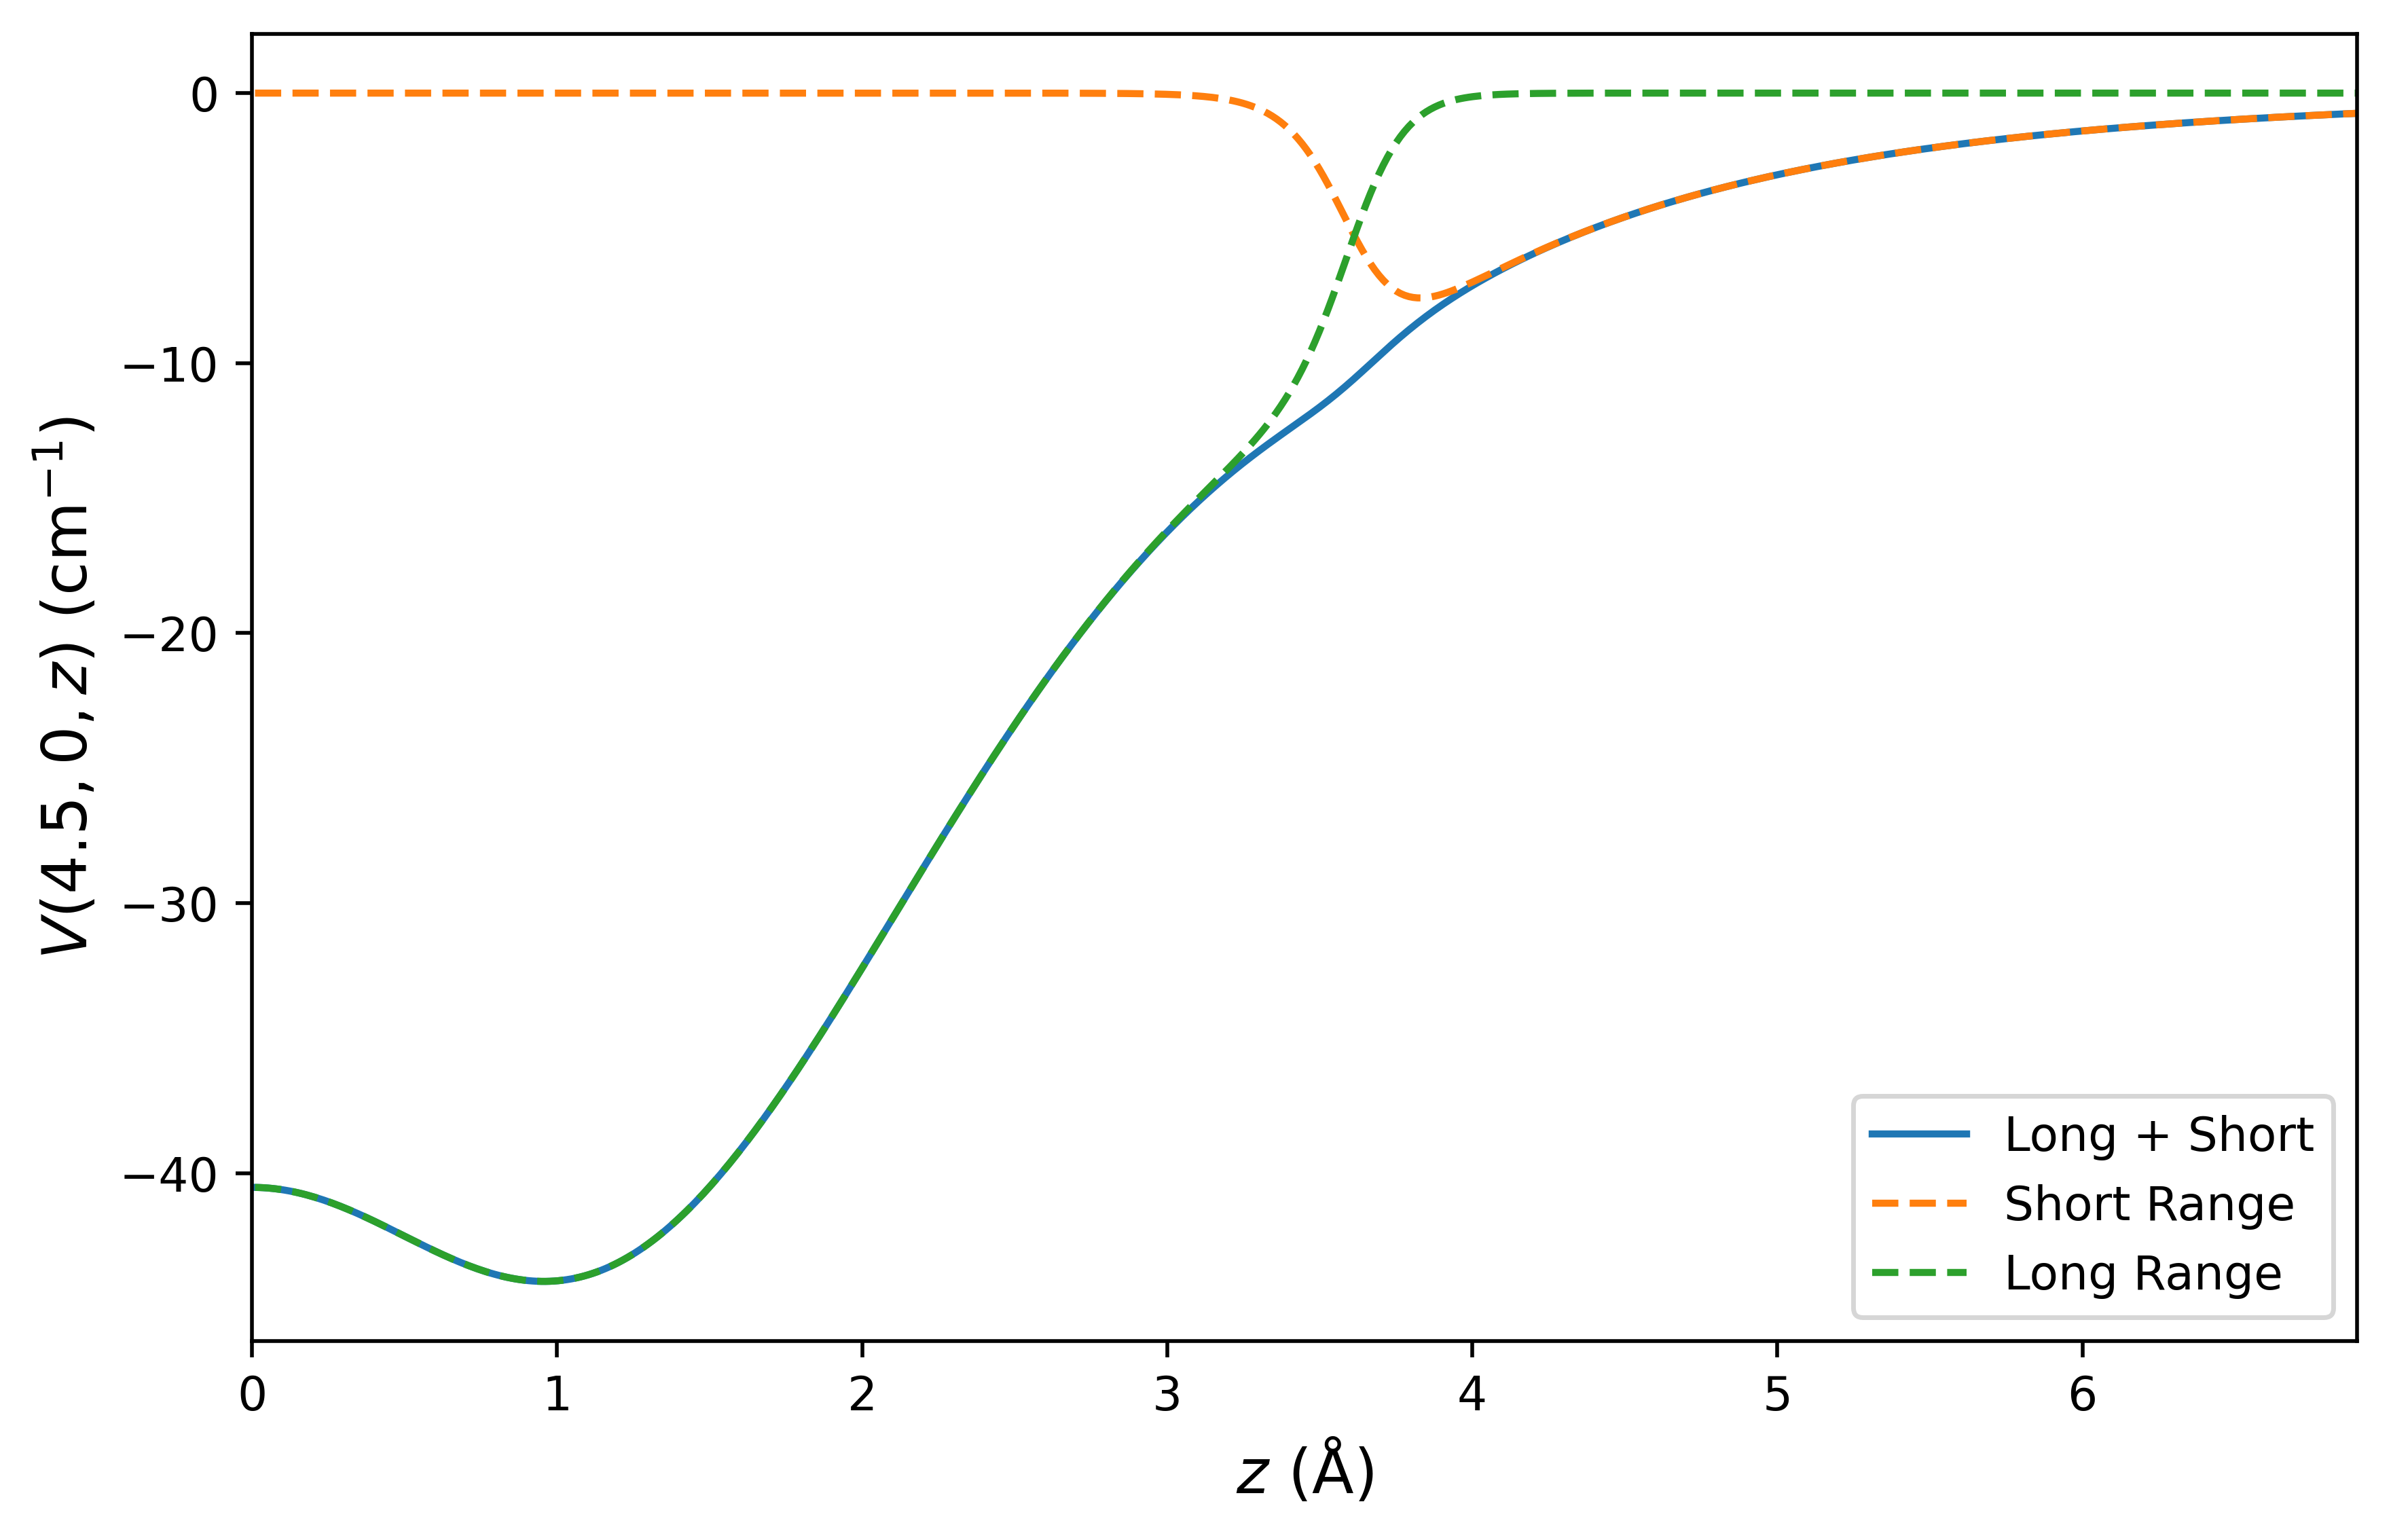

In [6]:
zplot = np.linspace(0.01,7,500)
xval = 4.5
yval = 0
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
plt.gcf().set_dpi(500)
ax.plot(zplot,long(xval,yval,zplot) + short(xval,yval,zplot),label='Long + Short')
ax.plot(zplot,long(xval,yval,zplot),'--',label='Short Range')
ax.plot(zplot,short(xval,yval,zplot),'--',label='Long Range')
ax.legend()
font_size = 13
plt.rc("font", size=10) 
ax.set_ylabel(r'$V(4.5,0,z)$ (cm$^{-1}$)', size=font_size)
ax.set_xlabel(r'$z$ (Å)', size=font_size)
#r0 = 0.5765366674E+01
#xp = np.sqrt(r0**2 - xval**2 - yval**2)
#ax.axvline(xp,linestyle='--',color='k',alpha=0.5)
#ax.set_ylim(-30,0)
ax.set_xlim(0,6.9)
plt.savefig('../figures/FigS3.svg')